In [1]:
import torchvision

print(torchvision.__version__)

0.22.0+cu118


In [1]:
import torch
from torch import optim as optim
from torchvision.models.detection import RetinaNet
from torchvision.models.detection.retinanet import RetinaNetHead
from torchvision.models import mobilenet_v3_large
from torchvision.models.detection.backbone_utils import IntermediateLayerGetter, FeaturePyramidNetwork

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0") # Use the first GPU
    print(f"Training on GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA not available. Training on CPU.")

Training on GPU: NVIDIA GeForce RTX 2060 SUPER


In [4]:
from torchvision.models.detection import RetinaNet
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.backbone_utils import _validate_trainable_layers
from torchvision.models import mobilenet_v3_large
from torchvision.ops import FeaturePyramidNetwork

# 1️⃣ Create a backbone
mobilenet_backbone = mobilenet_v3_large(weights="IMAGENET1K_V1").features

# Select layers that produce good feature maps for FPN
backbone_out_channels = [40, 112, 160]  # example MobileNetV3 feature map channels
fpn = FeaturePyramidNetwork(in_channels_list=backbone_out_channels, out_channels=256)

class MobileNetBackbone(torch.nn.Module):
    def __init__(self, body, fpn):
        super().__init__()
        self.body = body
        self.fpn = fpn

    def forward(self, x):
        features = []
        for i, block in enumerate(self.body):
            x = block(x)
            # Pick some layers for FPN
            if i in {3, 6, 12}:  # adjust indices
                features.append(x)
        # Create dict for FPN
        features = {str(idx): f for idx, f in enumerate(features)}
        return self.fpn(features)

    @property
    def out_channels(self):
        return 256

backbone = MobileNetBackbone(mobilenet_backbone, fpn)

# 2️⃣ Define anchor generator matching the number of FPN outputs
# If FPN outputs 3 feature maps, you need 3 tuples here
anchor_generator = AnchorGenerator(
    sizes=((32,), (64,), (128,)),       # one tuple per feature map
    aspect_ratios=((0.5, 1.0, 2.0),) * 3
)

# 3️⃣ Create RetinaNet model
model = RetinaNet(backbone, num_classes=2, anchor_generator=anchor_generator)
model.to(device)


RetinaNet(
  (backbone): MobileNetBackbone(
    (body): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivati

In [6]:
import torch
from torchvision.models.detection import RetinaNet
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

# Create a RetinaNet model with a ResNet-18 backbone
# pretrained=True loads weights from ImageNet for the backbone
backbone = resnet_fpn_backbone('resnet18', pretrained=True)

model = RetinaNet(backbone=backbone, num_classes=2)  # change to your number of classes
model.load_state_dict(torch.load("runs/retinanet_best_loss.pth"))



<All keys matched successfully>

In [3]:
import torch
import torch.nn as nn
from torchvision.models import resnet18
from torchvision.models._utils import IntermediateLayerGetter
from torchvision.ops import FeaturePyramidNetwork
from torchvision.models.detection.retinanet import RetinaNet

# ✅ Compatible AnchorGenerator import
try:
    from torchvision.models.detection.anchor_utils import AnchorGenerator
except ImportError:
    from torchvision.ops import AnchorGenerator

# ✅ Import ExtraFPNBlock for type-checking
try:
    from torchvision.ops.feature_pyramid_network import ExtraFPNBlock
except ImportError:
    from torchvision.models.detection.backbone_utils import ExtraFPNBlock


# --- Fix: fully compatible LastLevelP6P7 ---
class LastLevelP6P7(ExtraFPNBlock):
    """Adds extra pyramid levels (P6, P7) for RetinaNet, compatible with all TorchVision versions."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.p6 = nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1)
        self.p7 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, results, x=None, names=None):
        # Accept both (results, names) and (results, x, names)
        if names is None:
            names = []
        last_feature = results[-1]
        p6 = self.p6(last_feature)
        p7 = self.p7(self.relu(p6))
        results.extend([p6, p7])
        names.extend(["p6", "p7"])
        return results, names


# --- Build Small RetinaNet ---
def build_small_retinanet(num_classes=2):
    backbone = resnet18(weights=None)
    return_layers = {'layer2': '0', 'layer3': '1', 'layer4': '2'}
    in_channels_list = [128, 256, 512]
    out_channels = 64  # smaller feature maps

    # Get intermediate outputs
    backbone = IntermediateLayerGetter(backbone, return_layers=return_layers)
    fpn = FeaturePyramidNetwork(
    in_channels_list,
    out_channels,
    extra_blocks=LastLevelP6P7(out_channels, out_channels)  # ← Fix here
    )


    # Combine backbone + FPN
    class SmallBackbone(nn.Module):
        def __init__(self, body, fpn, out_channels):
            super().__init__()
            self.body = body
            self.fpn = fpn
            self.out_channels = out_channels

        def forward(self, x):
            x = self.body(x)
            x = self.fpn(x)
            return x

    backbone_with_fpn = SmallBackbone(backbone, fpn, out_channels)

    # Smaller anchors
    # 5 pyramid levels -> 5 size tuples
    anchor_generator = AnchorGenerator(
        sizes=((16,), (32,), (64,), (128,), (256,)),           # one size per level (P3..P7)
        aspect_ratios=((0.5, 1.0, 2.0),) * 5                   # same ratios for each level
    )


    model = RetinaNet(
        backbone=backbone_with_fpn,
        num_classes=num_classes,
        anchor_generator=anchor_generator
    )

    return model



model = build_small_retinanet(num_classes=2)
model.load_state_dict(torch.load("runs/retinanetretrain2_best_loss.pth"))


<All keys matched successfully>

In [11]:
!pip install torchinfo


In [22]:
import torch
import logging
from thop import profile

# Silence THOP’s register info logs
logging.getLogger("thop").setLevel(logging.ERROR)

def retina_summary(model, input_size=(1, 3, 640, 640)):
    """
    Prints YOLO-style summary for a custom RetinaNet (like your small RetinaNet):
    - Number of layers
    - Total parameters
    - Trainable parameters
    - Approximate GFLOPs (backbone + FPN)
    """
    model.eval()
    device = next(model.parameters()).device
    x = torch.randn(input_size).to(device)

    # Forward through backbone + FPN manually (returns dict of feature maps)
    with torch.no_grad():
        features = model.backbone(x)
        # features is an OrderedDict → get all output tensors
        feature_maps = list(features.values())

    # Estimate FLOPs of the backbone by summing feature map operations
    flops_total = 0
    for fmap in feature_maps:
        f_in = fmap.size(1)
        h, w = fmap.size(2), fmap.size(3)
        flops_total += f_in * h * w  # simple proxy for feature map cost

    # Parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_layers = len(list(model.modules()))

    # Compute approximate GFLOPs (scaled proxy)
    approx_flops = flops_total / 1e9

    print(f"\nRetinaNetShrimp summary: {total_layers} layers, "
          f"{total_params:,} parameters, {trainable_params:,} gradients, "
          f"~{approx_flops:.2f} GFLOPs (approximate, backbone + FPN)\n")

    return total_layers, total_params, trainable_params, approx_flops


# --- Example usage ---
model = build_small_retinanet(num_classes=2)
model.load_state_dict(torch.load("runs/retinanetretrain2_best_loss.pth", map_location="cpu"))

summary_stats = retina_summary(model)
print(summary_stats)



RetinaNetShrimp summary: 120 layers, 11,724,498 parameters, 11,724,498 gradients, ~0.00 GFLOPs (approximate, backbone + FPN)

(120, 11724498, 11724498, 0.0005456)


In [5]:
import torch
from torchvision.datasets import CocoDetection
from torchvision import transforms as T
import os

class CocoDetectionRetinaNet(CocoDetection):
    def __init__(self, root, annFile, transform=None):
        super(CocoDetectionRetinaNet, self).__init__(root, annFile)
        self.transform = transform

    def __getitem__(self, idx):
        img, ann = super().__getitem__(idx)

        boxes = []
        labels = []

        for obj in ann:
            if 'iscrowd' in obj and obj['iscrowd']:
                continue

            bbox = obj['bbox']
            x1 = bbox[0]
            y1 = bbox[1]
            x2 = bbox[0] + bbox[2]
            y2 = bbox[1] + bbox[3]

            boxes.append([x1, y1, x2, y2])
            labels.append(obj['category_id'])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        if self.transform is not None:
            img = self.transform(img)

        return img, target


In [8]:
!pip install pycocotools

In [6]:
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor

train_ds = CocoDetectionRetinaNet(root='cocoshrimpdataset/train',
                         annFile='cocoshrimpdataset/annotations/_annotations_train.coco.json',
                         transform=ToTensor())

test_ds = CocoDetectionRetinaNet(root='cocoshrimpdataset/test',
                        annFile='cocoshrimpdataset/annotations/_annotations_test.coco.json',
                        transform=ToTensor())

val_ds = CocoDetectionRetinaNet(root='cocoshrimpdataset/valid',
                       annFile='cocoshrimpdataset/annotations/_annotations_valid.coco.json',
                       transform=ToTensor())

loading annotations into memory...
Done (t=0.42s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


In [7]:
from torch.utils.data import DataLoader

train_dl = DataLoader(train_ds,
                      batch_size=8,
                      shuffle=True,
                      collate_fn=lambda batch: tuple(zip(*batch)))

test_dl = DataLoader(test_ds,
                     batch_size=8,
                     shuffle=False,
                     collate_fn=lambda batch: tuple(zip(*batch)))

val_dl = DataLoader(val_ds,
                    batch_size=8,
                    shuffle=False,
                    collate_fn=lambda batch: tuple(zip(*batch)))

In [7]:
import torch
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 20
best_loss = float("inf")  # Initialize with infinity
save_dir = "runs/"
os.makedirs(save_dir, exist_ok=True)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, targets in tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True):

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]


        if any(t['boxes'].numel() == 0 for t in targets):
            continue

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())


        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()

    avg_loss = running_loss / len(train_dl)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")


    if avg_loss < best_loss:
        best_loss = avg_loss
        best_model_path = os.path.join(save_dir, "retinanetretrain2_best_loss.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"🔥 New best model saved with loss {best_loss:.4f} at {best_model_path}")
    else:
        print(f"No improvement. Best loss remains {best_loss:.4f}")


Using device: cuda


Epoch 1/20: 100%|██████████| 518/518 [04:09<00:00,  2.08it/s]


Epoch [1/20] - Loss: 0.3480
🔥 New best model saved with loss 0.3480 at runs/retinanetretrain2_best_loss.pth


Epoch 2/20: 100%|██████████| 518/518 [03:48<00:00,  2.26it/s]


Epoch [2/20] - Loss: 0.3320
🔥 New best model saved with loss 0.3320 at runs/retinanetretrain2_best_loss.pth


...

Epoch [18/20] - Loss: 0.1828
No improvement. Best loss remains 0.1825


Epoch 19/20: 100%|██████████| 518/518 [03:48<00:00,  2.27it/s]


Epoch [19/20] - Loss: 0.1760
🔥 New best model saved with loss 0.1760 at runs/retinanetretrain2_best_loss.pth


Epoch 20/20: 100%|██████████| 518/518 [03:46<00:00,  2.28it/s]

Epoch [20/20] - Loss: 0.1720
🔥 New best model saved with loss 0.1720 at runs/retinanetretrain2_best_loss.pth


In [8]:
import torch
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model weights correctly
# model.load_state_dict(torch.load("runs/retinanetretrain2_best_loss.pth", map_location="cpu"))
model.to(device)
model.eval()

running_box_loss = 0.0

with torch.no_grad():
    # ✅ temporarily enable training mode to get losses
    model.train()
    for images, targets in tqdm(test_dl, desc="Evaluating (Loss)"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        if any(t['boxes'].numel() == 0 for t in targets):
            continue

        # Now returns a dict with losses
        loss_dict = model(images, targets)
        running_box_loss += loss_dict["bbox_regression"].item()

    model.eval()  # switch back to eval mode

avg_box_loss = running_box_loss / len(test_dl)
print(f"Average Box Loss on Test Set: {avg_box_loss:.4f}")


Using device: cuda


Evaluating (Loss): 100%|██████████| 25/25 [00:05<00:00,  4.63it/s]

Average Box Loss on Test Set: 0.2766


In [9]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torch

metric = MeanAveragePrecision(iou_type="bbox")  # default computes mAP@0.5:0.95
# You can also specify only IoU=0.5 if desired:
# metric = MeanAveragePrecision(iou_thresholds=[0.5])

model.eval()
with torch.no_grad():
    for images, targets in tqdm(test_dl, desc="Evaluating (mAP)"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        preds = model(images)  # outputs: list of dicts [{boxes, scores, labels}, ...]

        # Format predictions and targets for torchmetrics
        preds = [
            {
                "boxes": p["boxes"].detach().cpu(),
                "scores": p["scores"].detach().cpu(),
                "labels": p["labels"].detach().cpu(),
            }
            for p in preds
        ]
        targets = [
            {
                "boxes": t["boxes"].detach().cpu(),
                "labels": t["labels"].detach().cpu(),
            }
            for t in targets
        ]

        metric.update(preds, targets)

# ✅ Compute final results
results = metric.compute()
print(results)
print(f"mAP@50: {results['map_50']:.4f}")


Evaluating (mAP):   0%|          | 0/25 [00:00<?, ?it/s]e:\PD1ModelTrainings\DLenv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
Evaluating (mAP): 100%|██████████| 25/25 [00:05<00:00,  4.25it/s]


{'map': tensor(0.4292), 'map_50': tensor(0.7956), 'map_75': tensor(0.4149), 'map_small': tensor(0.4377), 'map_medium': tensor(0.1855), 'map_large': tensor(0.1849), 'mar_1': tensor(0.0161), 'mar_10': tensor(0.1339), 'mar_100': tensor(0.5426), 'mar_small': tensor(0.5513), 'mar_medium': tensor(0.2940), 'mar_large': tensor(0.2733), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}
mAP@50: 0.7956


In [10]:
import torch
import time
from tqdm import tqdm

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

total_time = 0.0
num_images = 0

with torch.no_grad():
    for images, targets in tqdm(test_dl, desc="Measuring Inference Time"):
        images = [img.to(device) for img in images]

        # Measure inference time
        torch.cuda.synchronize() if device.type == "cuda" else None
        start_time = time.time()

        preds = model(images)

        torch.cuda.synchronize() if device.type == "cuda" else None
        end_time = time.time()

        # Compute average per image in batch
        batch_time = (end_time - start_time)
        total_time += batch_time
        num_images += len(images)

avg_inference_time = total_time / num_images
print(f"⚡ Average inference time per image: {avg_inference_time:.4f} seconds")
print(f"🧮 ≈ {1/avg_inference_time:.2f} FPS")



Measuring Inference Time: 100%|██████████| 25/25 [00:05<00:00,  4.51it/s]

⚡ Average inference time per image: 0.0209 seconds
🧮 ≈ 47.80 FPS


In [17]:
with torch.no_grad():
    for idx, (images, _) in enumerate(tqdm(test_dl, desc="Per-image Timing")):
        images = [img.to(device) for img in images]

        torch.cuda.synchronize() if device.type == "cuda" else None
        start = time.time()

        preds = model(images)

        torch.cuda.synchronize() if device.type == "cuda" else None
        end = time.time()

        print(f"Image {idx+1}: {(end - start):.4f} seconds")


Per-image Timing:   4%|▍         | 1/25 [00:00<00:11,  2.14it/s]

Image 1: 0.4001 seconds


Per-image Timing:   8%|▊         | 2/25 [00:00<00:07,  2.90it/s]

Image 2: 0.2017 seconds


Per-image Timing:  12%|█▏        | 3/25 [00:00<00:06,  3.47it/s]

...

Image 21: 0.1554 seconds
Image 22: 0.1564 seconds


Per-image Timing:  92%|█████████▏| 23/25 [00:05<00:00,  4.54it/s]

Image 23: 0.1579 seconds


Per-image Timing: 100%|██████████| 25/25 [00:05<00:00,  4.26it/s]

Image 24: 0.1731 seconds
Image 25: 0.1078 seconds


In [18]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for images, targets in test_dl:
        imgs = [img.to(device) for img in images]
        preds = model(imgs)  # list of dicts: boxes, scores, labels
        for p in preds[:3]:
            boxes = p['boxes'].cpu()
            scores = p['scores'].cpu()
            areas = (boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])
            print("Top scores:", scores[:10])
            print("Box areas:", areas[:10])
        break


Top scores: tensor([0.9976, 0.9918, 0.9864, 0.9836, 0.9667, 0.9601, 0.9509, 0.9434, 0.8900,
        0.8817])
Box areas: tensor([503.4057, 586.9394, 412.2167, 508.4028, 469.6603, 556.8061, 483.9330,
        452.7509, 222.3839, 440.3140])
Top scores: tensor([0.9908, 0.9663, 0.8920, 0.8788, 0.7546, 0.6594, 0.6209, 0.6134, 0.5781,
        0.4690])
Box areas: tensor([827.7786, 441.7923, 301.1284, 237.1593, 386.1974, 483.1268, 247.8794,
        418.8557, 650.3307, 274.3599])
Top scores: tensor([0.9979, 0.9968, 0.9940, 0.9891, 0.9871, 0.9870, 0.9845, 0.9818, 0.9811,
        0.9795])
Box areas: tensor([516.7466, 260.4321, 618.7466, 297.5417, 290.3647, 271.1687, 270.8685,
        468.5873, 218.5014, 448.7791])


Using device: cuda
⚙️ Inference Time: 130.45 ms
💾 GPU Memory Usage: 356.08 MB
✅ Output image saved at: output_detected2.jpg


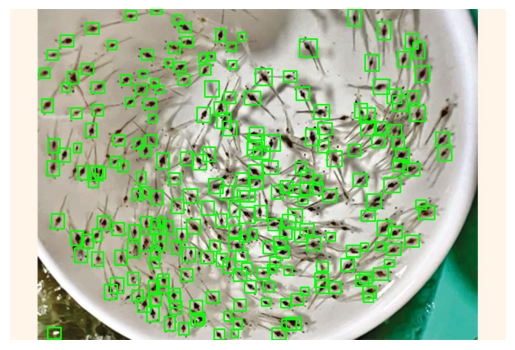

In [19]:
import torch
import torchvision
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.models.detection import RetinaNet
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)
image_path = "test.jpg"
save_path = "output_detected2.jpg"
model.eval()
# --- LOAD IMAGE ---
image = Image.open(image_path).convert("RGB")
transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(image).to(device)

# --- CLEAR GPU CACHE BEFORE INFERENCE ---
if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# --- INFERENCE (Measure time + GPU usage) ---
with torch.no_grad():
    if device.type == "cuda":
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)
        start_event.record()
    else:
        start_time = time.time()

    outputs = model([img_tensor])

    if device.type == "cuda":
        end_event.record()
        torch.cuda.synchronize()
        inference_time_ms = start_event.elapsed_time(end_event)
        max_memory = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
    else:
        inference_time_ms = (time.time() - start_time) * 1000
        max_memory = 0.0

# --- PRINT PERFORMANCE ---
print(f"⚙️ Inference Time: {inference_time_ms:.2f} ms")
print(f"💾 GPU Memory Usage: {max_memory:.2f} MB")

# --- PROCESS OUTPUT ---
output = outputs[0]
boxes = output["boxes"].cpu().numpy()
scores = output["scores"].cpu().numpy()
labels = output["labels"].cpu().numpy()

# --- DRAW DETECTIONS ---
image_cv = np.array(image)
image_cv = cv2.cvtColor(image_cv, cv2.COLOR_RGB2BGR)

confidence_threshold = 0.5
for box, score, label in zip(boxes, scores, labels):
    if score < confidence_threshold:
        continue
    x1, y1, x2, y2 = box.astype(int)
    color = (0, 255, 0)
    cv2.rectangle(image_cv, (x1, y1), (x2, y2), color, 2)

# --- SAVE OUTPUT ---
cv2.imwrite(save_path, image_cv)
print(f"✅ Output image saved at: {save_path}")

# --- SHOW OUTPUT ---
image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()
